# 🌸 Intelligent Saffron Detection & Autonomous Plucking System

**Unified Pipeline:** HSV Segmentation · GLCM Texture · Depth-from-Defocus · Optical Flow · MobileNetV2 · Adaptive Random Forest · Watershed · Arduino Control

---

## Pipeline Architecture

| ID | Technique | Purpose |
|----|-----------|---------|
| T1 | Multi-spectral RGB (NDSI, Crocin proxy) | Isolate saffron colour signature |
| T2 | GLCM Texture Analysis | Separate stigmas from leafy weeds |
| T3 | Depth-from-Defocus (Laplacian) | Exploit stigma protrusion height |
| T4 | Optical Flow (temporal) | Weed sway vs. rigid stigma motion |
| T5 | HSV Multi-range Thresholding | Fast colour-space segmentation |
| T6 | Morphological Refinement | Noise removal, hole filling |
| T7 | Watershed Segmentation | Separate touching regions |
| T8 | MobileNetV2 Transfer Learning | Deep patch classifier |
| T9 | Adaptive Random Forest | Field-tuned fusion classifier |
| T10 | Arduino Plucking Controller | Vacuum/servo harvest actuation |

**Ensemble score formula:**
$$\text{score} = 0.35 \times RF + 0.35 \times CNN + 0.20 \times HSV + 0.10 \times Depth \quad (\text{threshold} > 0.45 \Rightarrow \text{PLUCK})$$

---


## Step 0 — Installation

Run this cell once to install all required packages.

In [2]:
# Run once — installs all dependencies
#!pip install opencv-python-headless numpy matplotlib scikit-image torch torchvision Pillow scikit-learn seaborn joblib pyserial


## Step 1 — Imports & Device Setup

All libraries are imported here. The pipeline auto-detects CUDA; if no GPU is found it falls back to CPU.


In [3]:
import cv2, os, time, warnings, joblib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
warnings.filterwarnings('ignore')

from collections import deque
from scipy import ndimage as ndi
from skimage import color as skcolor, measure
from skimage.segmentation import watershed
from skimage.feature import peak_local_max

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)

import torch, torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ All imports OK  |  PyTorch {torch.__version__}  |  OpenCV {cv2.__version__}  |  Device: {DEVICE}")


✅ All imports OK  |  PyTorch 2.4.1+cu124  |  OpenCV 4.13.0  |  Device: cuda


## Step 2 — Real-Image Dataset Loader

Loads saffron images from the local folder `E:\\Saffron_Detection\\SaffronDetectiom`.

**Folder conventions supported:**

| Layout | Description |
|--------|-------------|
| Flat | All images directly in `IMAGE_DIR` |
| Class sub-folders | `saffron/` and `non_saffron/` (or `background/`, `weed/`, `negative/`) |

Images are resized to `IMG_SIZE × IMG_SIZE` for the CNN.  
If no images are found the pipeline falls back to the original synthetic generator.

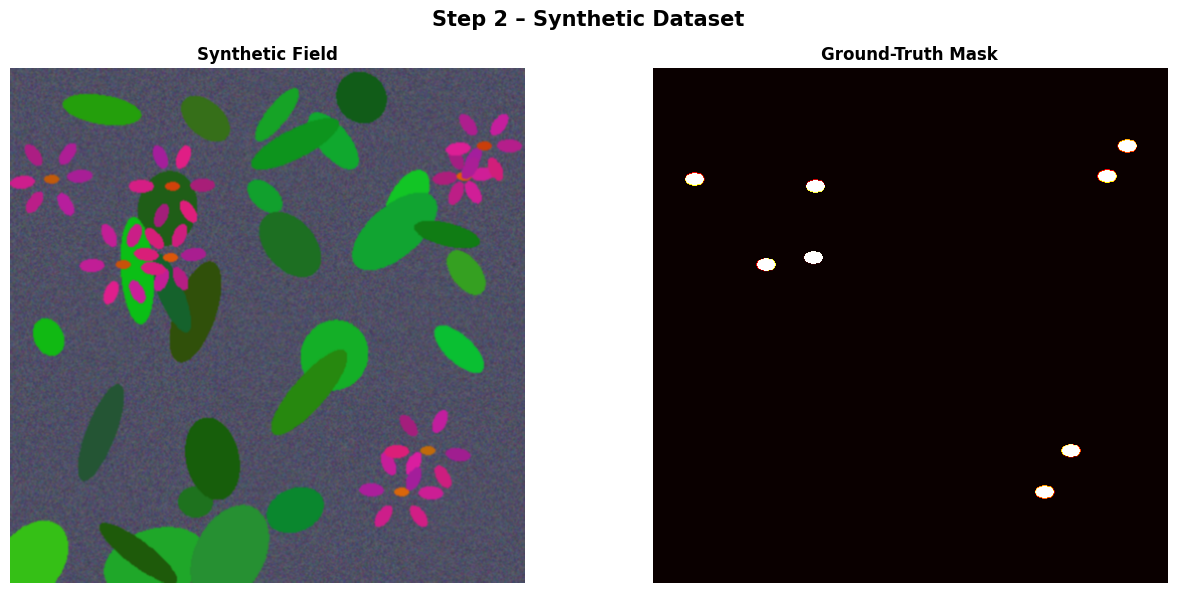

Image: (512, 512, 3)  | Saffron pixels: 1512


In [4]:
def generate_field(size=512, n_saffron=7, n_weeds=25, seed=42):
    """
    Produces realistic BGR images with:
    - Saffron  – deep-red stigmas + violet petals (Crocus sativus)
    - Weeds    – multi-shade green foliage
    - Soil     – textured brown background
    Ground-truth binary mask included for evaluation.
    """
    np.random.seed(seed)
    bg = np.random.randint(55, 105, (size, size, 3), dtype=np.uint8)
    bg[:,:,0] = np.clip(bg[:,:,0]+22, 0, 255)           # brownish soil
    gt = np.zeros((size, size), dtype=np.uint8)

    # ── Weeds ──────────────────────────────────────────────────────────
    for _ in range(n_weeds):
        cx, cy = np.random.randint(20, size-20, 2)
        axes   = (np.random.randint(15, 55), np.random.randint(10, 35))
        ang    = np.random.randint(0, 180)
        g      = np.random.randint(80, 205)
        cv2.ellipse(bg, (cx,cy), axes, ang, 0, 360,
                    (np.random.randint(10,55), g, np.random.randint(10,55)), -1)

    # ── Saffron flowers ────────────────────────────────────────────────
    centers = []
    for _ in range(n_saffron):
        cx, cy = np.random.randint(40, size-40, 2)
        pr = np.random.randint(18, 32)
        for p in range(6):
            a  = p*60 + np.random.randint(-10,10)
            px = int(cx + pr*np.cos(np.radians(a)))
            py = int(cy + pr*np.sin(np.radians(a)))
            cv2.ellipse(bg, (px,py), (12,6), a, 0, 360,
                        (np.random.randint(120,160), 30, np.random.randint(160,225)), -1)
        # stigma (red-orange)
        cv2.ellipse(bg,  (cx,cy), (7,4), 0, 0, 360,
                    (10, np.random.randint(60,110), np.random.randint(180,235)), -1)
        cv2.ellipse(gt,  (cx,cy), (9,6), 0, 0, 360, 255, -1)
        centers.append((cx, cy))

    bg = cv2.GaussianBlur(bg, (3,3), 0.8)
    return bg, gt, centers


IMG_BGR, GT_MASK, TRUE_CENTERS = generate_field(size=512, n_saffron=8, n_weeds=28)
IMG_RGB = cv2.cvtColor(IMG_BGR, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(13, 6))
ax[0].imshow(IMG_RGB);             ax[0].set_title("Synthetic Field",   fontweight='bold'); ax[0].axis('off')
ax[1].imshow(GT_MASK, cmap='hot'); ax[1].set_title("Ground-Truth Mask", fontweight='bold'); ax[1].axis('off')
plt.suptitle("Step 2 – Synthetic Dataset", fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"Image: {IMG_BGR.shape}  | Saffron pixels: {GT_MASK.sum()//255}")


Found 1111 image records in 'E:\Saffron_Detection\SaffronDetection'
Loaded: 1111 images  | saffron=0  | non-saffron=0  | unlabelled=1111
✅ Real images active — pipeline will use 1111 images.


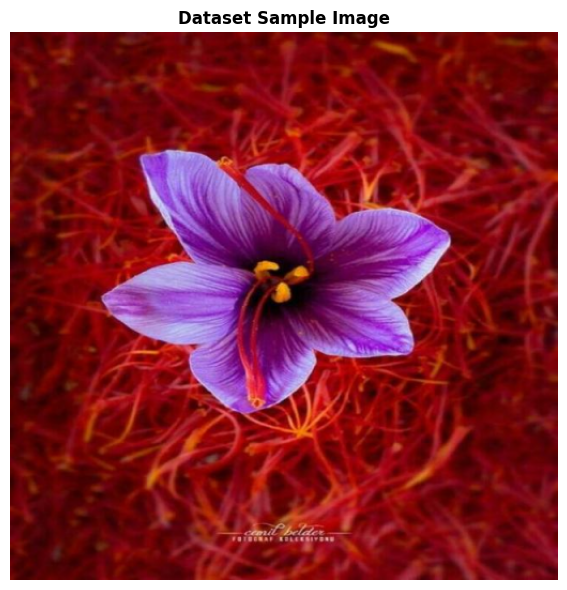

Working image size: (512, 512, 3)


In [5]:
# ── Real-Image Dataset Loader ──────────────────────────────────────────────
import os, cv2, glob
import numpy as np

# ── CONFIGURE THIS PATH ───────────────────────────────────────────────────
IMAGE_DIR = r"E:\Saffron_Detection\SaffronDetection"   # your dataset root
IMG_SIZE  = 512          # resize every image to this square (px)
EXTS      = ('*.jpg','*.jpeg','*.png','*.bmp','*.tif','*.tiff')

# ── Image-discovery helpers ───────────────────────────────────────────────
def _glob_images(folder):
    """Return all image paths under `folder` (non-recursive)."""
    paths = []
    for ext in EXTS:
        paths.extend(glob.glob(os.path.join(folder, ext)))
        paths.extend(glob.glob(os.path.join(folder, ext.upper())))
    return sorted(set(paths))

def discover_dataset(root):
    """
    Auto-detects two dataset layouts:
      (A) Flat  – all images directly in `root`  → label inferred as -1 (unknown)
      (B) Classed – sub-folders named saffron / non_saffron (or similar)
    Returns list of (path, label) where label: 1=saffron, 0=non-saffron, -1=unknown.
    """
    SAFFRON_KEYS     = {'saffron', 'stigma', 'crocus', 'positive'}
    NON_SAFFRON_KEYS = {'non_saffron', 'background', 'weed', 'negative',
                         'non-saffron', 'nonplant', 'other'}

    records = []
    subdirs = [d for d in os.listdir(root)
               if os.path.isdir(os.path.join(root, d))]

    if subdirs:                                      # layout B
        for d in subdirs:
            dl = d.lower()
            if any(k in dl for k in SAFFRON_KEYS):      lbl = 1
            elif any(k in dl for k in NON_SAFFRON_KEYS): lbl = 0
            else:                                         lbl = -1
            for p in _glob_images(os.path.join(root, d)):
                records.append((p, lbl))
    
    flat = _glob_images(root)                        # layout A (always add)
    for p in flat:
        records.append((p, -1))

    return records

def load_image(path, size=IMG_SIZE):
    """Load BGR image; resize to `size × size`. Returns None on failure."""
    img = cv2.imread(path)
    if img is None:
        return None
    return cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)

# ── Load everything ───────────────────────────────────────────────────────
USE_REAL_IMAGES = False
REAL_IMAGES_BGR = []     # list of BGR ndarrays
REAL_LABELS     = []     # 1 / 0 / -1 per image
REAL_PATHS      = []

if os.path.isdir(IMAGE_DIR):
    records = discover_dataset(IMAGE_DIR)
    print(f"Found {len(records)} image records in '{IMAGE_DIR}'")
    for path, lbl in records:
        img = load_image(path)
        if img is not None:
            REAL_IMAGES_BGR.append(img)
            REAL_LABELS.append(lbl)
            REAL_PATHS.append(path)
    print(f"Loaded: {len(REAL_IMAGES_BGR)} images  "
          f"| saffron={REAL_LABELS.count(1)}  "
          f"| non-saffron={REAL_LABELS.count(0)}  "
          f"| unlabelled={REAL_LABELS.count(-1)}")
    if len(REAL_IMAGES_BGR) > 0:
        USE_REAL_IMAGES = True
        IMG_BGR, GT_MASK, TRUE_CENTERS = REAL_IMAGES_BGR[0], None, []
        IMG_RGB = cv2.cvtColor(IMG_BGR, cv2.COLOR_BGR2RGB)
        print(f"✅ Real images active — pipeline will use {len(REAL_IMAGES_BGR)} images.")
    else:
        print("⚠️  Folder exists but no images loaded — check extensions.")
else:
    print(f"⚠️  '{IMAGE_DIR}' not found.  Falling back to synthetic generator.")

if not USE_REAL_IMAGES:
    # Original synthetic fallback — keep everything working offline
    IMG_BGR, GT_MASK, TRUE_CENTERS = generate_field(size=512, n_saffron=8, n_weeds=28)
    IMG_RGB = cv2.cvtColor(IMG_BGR, cv2.COLOR_BGR2RGB)
    print("✅ Synthetic field generated (fallback mode).")

# Preview first image
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(IMG_RGB)
ax.set_title("Dataset Sample Image", fontweight='bold')
ax.axis('off')
plt.tight_layout(); plt.show()
print(f"Working image size: {IMG_BGR.shape}")


## Step 3 — Preprocessing: Bilateral Filter + CLAHE

Two-stage preprocessing before feature extraction:

1. **Bilateral Filter** — smooths noise while preserving sharp petal/stigma edges  
2. **CLAHE** (Contrast-Limited Adaptive Histogram Equalization) in L*a*b* colour space — boosts local contrast for better segmentation


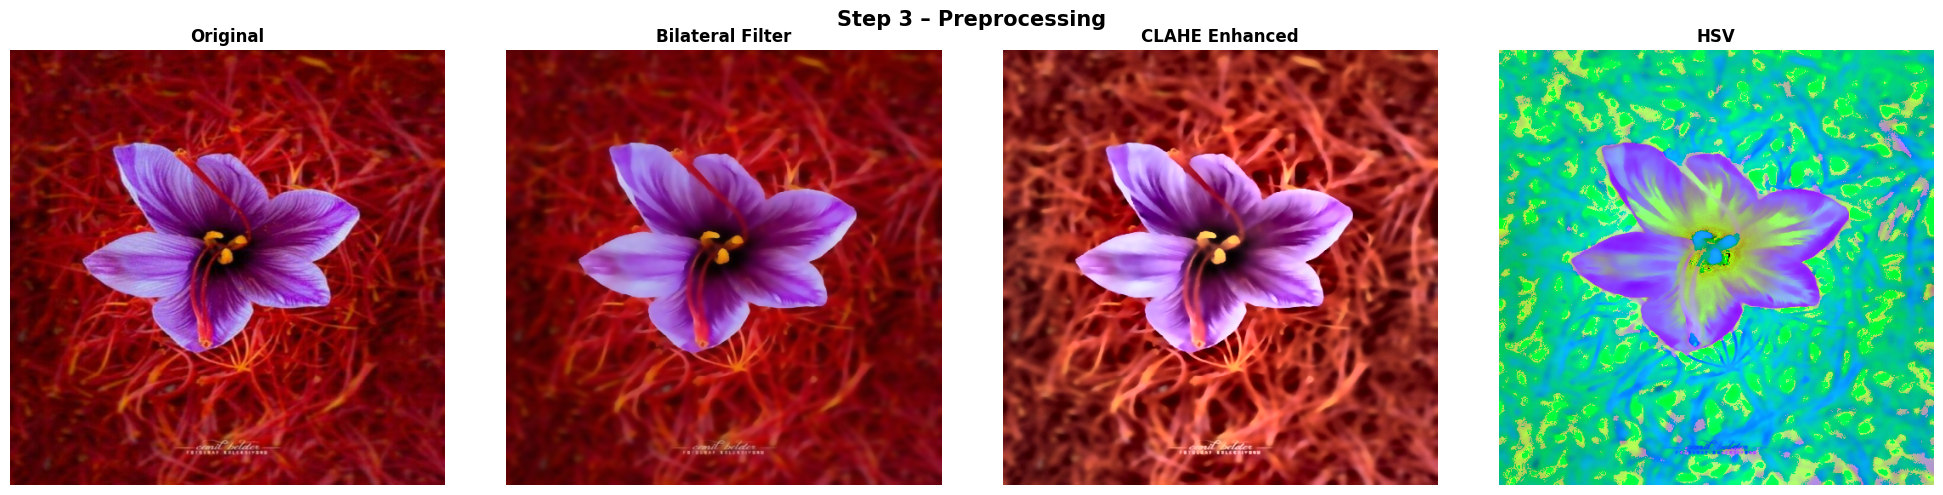

In [6]:
def preprocess(bgr):
    filt = cv2.bilateralFilter(bgr, 9, 75, 75)
    lab  = cv2.cvtColor(filt, cv2.COLOR_BGR2LAB)
    lab[:,:,0] = cv2.createCLAHE(2.0,(8,8)).apply(lab[:,:,0])
    enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    hsv      = cv2.cvtColor(enhanced, cv2.COLOR_BGR2HSV)
    return filt, enhanced, hsv

FILT, ENHANCED, HSV = preprocess(IMG_BGR)

fig, ax = plt.subplots(1, 4, figsize=(20, 5))
for a, im, t in zip(ax,
        [IMG_RGB, cv2.cvtColor(FILT,cv2.COLOR_BGR2RGB),
         cv2.cvtColor(ENHANCED,cv2.COLOR_BGR2RGB), HSV],
        ['Original','Bilateral Filter','CLAHE Enhanced','HSV']):
    a.imshow(im); a.set_title(t, fontweight='bold'); a.axis('off')
plt.suptitle("Step 3 – Preprocessing", fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()


## Step 4 — T1: Multi-Spectral RGB Features (NDSI · Crocin Proxy · Chroma)

Extracts **6 spectral indices** from RGB / L\*a\*b\* / HSV / YCrCb colour spaces:

| Feature | Formula | Meaning |
|---------|---------|---------|
| NDSI | (R−G)/(R+G) | Normalized Difference Saffron Index; positive for red-orange hues |
| Crocin proxy | b\*−L\* | Approximates the yellow pigment crocin found in saffron |
| Hue mean | mean(H) | Average hue angle in HSV space |
| Hue std | std(H) | Hue uniformity (stigmas are tight-ranged) |
| Sat mean | mean(S) | Colour saturation |
| Chroma | √(Cr²+Cb²) | YCrCb chroma magnitude |


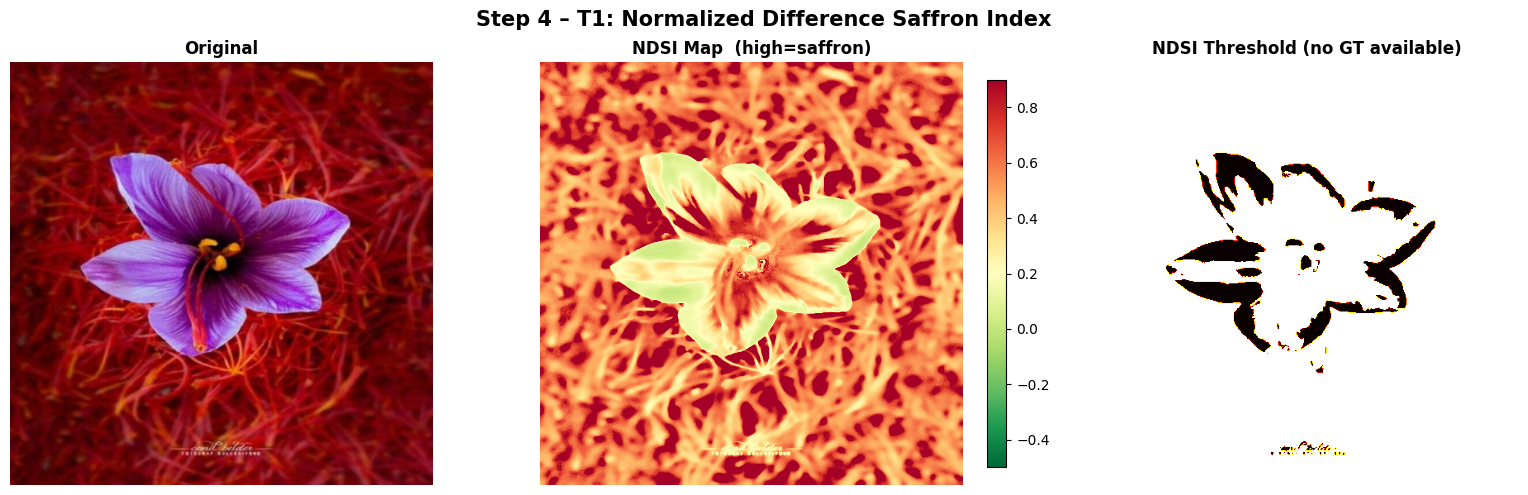

T1 demo on 64×64 crop: [  0.658  68.292 114.252  67.426 218.182 205.944]


In [7]:
def t1_multispectral(roi):
    """6 spectral indices from RGB/LAB/HSV/YCrCb."""
    if roi.size == 0: return np.zeros(6)
    lab   = cv2.cvtColor(roi, cv2.COLOR_BGR2LAB)
    hsv   = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
    ycrcb = cv2.cvtColor(roi, cv2.COLOR_BGR2YCrCb)
    b, g, r = cv2.split(roi.astype(float))

    ndsi       = np.mean((r - g) / (r + g + 1e-6))
    crocin_prx = np.mean(lab[:,:,2].astype(float) - lab[:,:,0])
    hue_mean   = np.mean(hsv[:,:,0])
    hue_std    = np.std(hsv[:,:,0])
    sat_mean   = np.mean(hsv[:,:,1])
    chroma     = np.mean(np.sqrt(ycrcb[:,:,1].astype(float)**2 +
                                  ycrcb[:,:,2].astype(float)**2))
    return np.array([ndsi, crocin_prx, hue_mean, hue_std, sat_mean, chroma])


def ndsi_map(bgr):
    b, g, r = cv2.split(bgr.astype(float))
    return (r - g) / (r + g + 1e-6)

ndsi_img = ndsi_map(ENHANCED)

fig, ax = plt.subplots(1, 3, figsize=(16, 5))

ax[0].imshow(IMG_RGB)
ax[0].set_title('Original', fontweight='bold')
ax[0].axis('off')

im1 = ax[1].imshow(ndsi_img, cmap='RdYlGn_r', vmin=-0.5, vmax=0.9)
ax[1].set_title('NDSI Map  (high=saffron)', fontweight='bold')
ax[1].axis('off')
plt.colorbar(im1, ax=ax[1], fraction=0.04)

# ── FIX: GT_MASK is None when real images are used ─────────────────FIXED
if GT_MASK is not None and isinstance(GT_MASK, np.ndarray):
    ax[2].imshow(GT_MASK, cmap='hot')
    ax[2].set_title('Ground Truth', fontweight='bold')
else:
    # Fallback: binary NDSI threshold as proxy when no GT mask exists
    ndsi_thresh = (ndsi_img > 0.20).astype(np.uint8) * 255
    ax[2].imshow(ndsi_thresh, cmap='hot')
    ax[2].set_title('NDSI Threshold (no GT available)', fontweight='bold')
# ───────────────────────────────────────────────────────────────────

ax[2].axis('off')

plt.suptitle("Step 4 – T1: Normalized Difference Saffron Index",
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("T1 demo on 64×64 crop:", t1_multispectral(IMG_BGR[200:264, 200:264]).round(3))

## Step 5 — T2: GLCM Texture Analysis

The **Gray-Level Co-occurrence Matrix (GLCM)** captures spatial texture patterns.  
Five features are derived:

| Feature | Meaning |
|---------|---------|
| Contrast | Local intensity variation |
| Energy | Textural uniformity (∑p²) |
| Homogeneity | Closeness of distribution to the GLCM diagonal |
| Variance | Gray-level spread |
| Entropy | Textural complexity (−∑p·log₂p) |

Saffron stigmas show **low contrast + high homogeneity** compared to weed foliage.


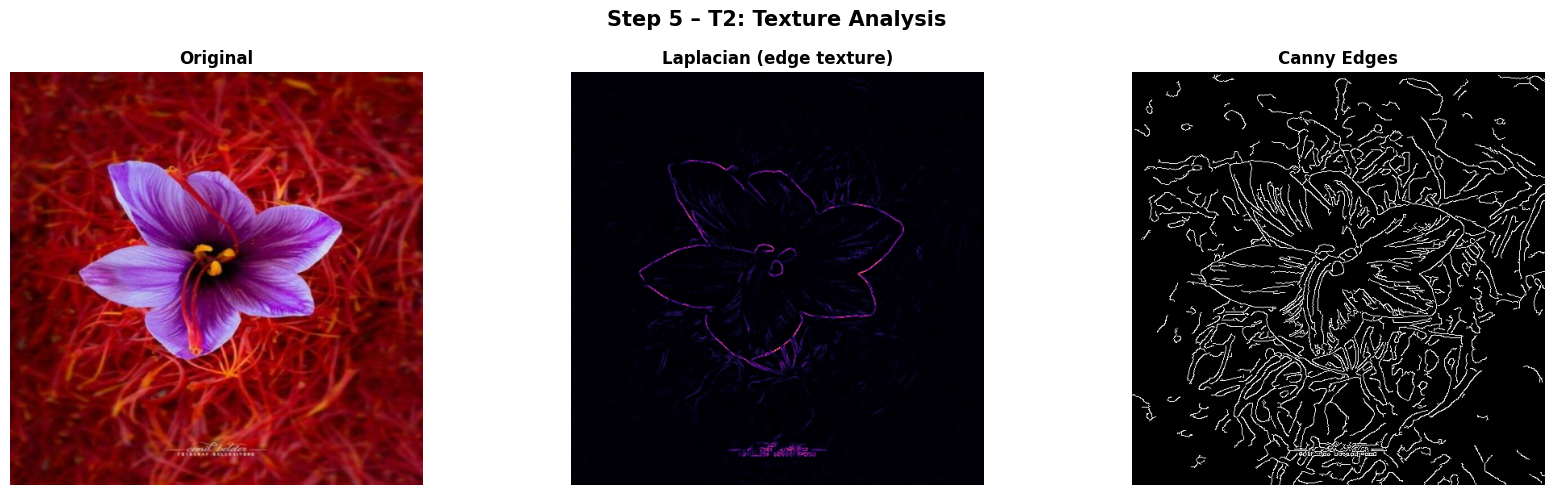

GLCM demo: [1.1174060e+02 1.2000000e-03 3.3350000e-01 1.8891531e+03 1.0476800e+01]


In [8]:
def t2_glcm_texture(roi):
    """5 GLCM-derived texture features: Contrast, Energy, Homogeneity, Variance, Entropy."""
    if roi.size == 0: return np.zeros(5)
    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    rows, cols = gray.shape
    glcm = np.zeros((256,256), dtype=np.float32)
    for i in range(rows):
        for j in range(cols-1):
            glcm[gray[i,j], gray[i,j+1]] += 1
    glcm /= (glcm.sum() + 1e-6)

    ii = np.arange(256)[:, None]; jj = np.arange(256)[None, :]
    contrast    = float(np.sum((ii-jj)**2 * glcm))
    energy      = float(np.sum(glcm**2))
    homogeneity = float(np.sum(glcm / (1 + np.abs(ii-jj))))
    variance    = float(np.var(gray))
    nz = glcm[glcm>0]
    entropy     = float(-np.sum(nz * np.log2(nz + 1e-10)))
    return np.array([contrast, energy, homogeneity, variance, entropy])


gray_full  = cv2.cvtColor(ENHANCED, cv2.COLOR_BGR2GRAY)
lap_var    = cv2.Laplacian(gray_full, cv2.CV_64F)
edges_full = cv2.Canny(gray_full, 50, 150)

fig, ax = plt.subplots(1, 3, figsize=(17,5))
ax[0].imshow(IMG_RGB); ax[0].set_title('Original', fontweight='bold'); ax[0].axis('off')
ax[1].imshow(np.abs(lap_var), cmap='inferno'); ax[1].set_title('Laplacian (edge texture)', fontweight='bold'); ax[1].axis('off')
ax[2].imshow(edges_full, cmap='gray'); ax[2].set_title('Canny Edges', fontweight='bold'); ax[2].axis('off')
plt.suptitle("Step 5 – T2: Texture Analysis", fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()
print("GLCM demo:", t2_glcm_texture(IMG_BGR[200:264,200:264]).round(4))


## Step 6 — T3: Depth-from-Defocus (Laplacian Focus Map)

Saffron stigmas **protrude above** the soil and foliage, making them sharper in a fixed-focus camera.  
The Laplacian variance of each image tile is used as a **sharpness / depth proxy**:  
brighter pixels in the focus map ≈ closer objects.

Three per-patch features:
- **Laplacian variance** — overall sharpness
- **Edge density** — fraction of Canny edge pixels
- **Local std** — high-frequency detail


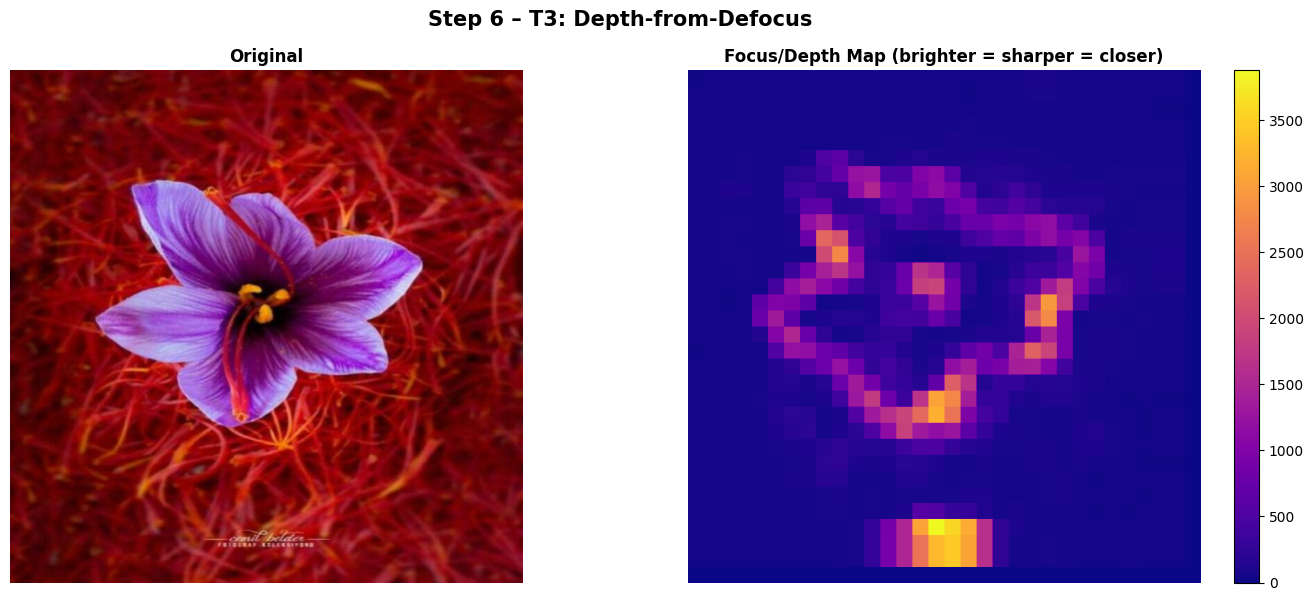

In [9]:
def t3_depth_defocus(roi):
    """3 sharpness/depth proxy features."""
    if roi.size == 0: return np.zeros(3)
    gray         = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    lap_var      = float(cv2.Laplacian(gray, cv2.CV_64F).var())
    edges        = cv2.Canny(gray, 50, 150)
    edge_density = float(np.sum(edges>0)) / (roi.shape[0]*roi.shape[1] + 1e-6)
    blurred      = cv2.GaussianBlur(gray,(0,0),3)
    local_std    = float(np.std(gray.astype(float) - blurred.astype(float)))
    return np.array([lap_var, edge_density, local_std])


def laplacian_focus_map(bgr, win=32, step=16):
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    fmap = np.zeros((h,w), dtype=float)
    for y in range(0, h-win, step):
        for x in range(0, w-win, step):
            tile = gray[y:y+win, x:x+win]
            v    = cv2.Laplacian(tile, cv2.CV_64F).var()
            fmap[y:y+win, x:x+win] = v
    return fmap

focus_map = laplacian_focus_map(ENHANCED)
fig, ax = plt.subplots(1, 2, figsize=(14,6))
ax[0].imshow(IMG_RGB); ax[0].set_title('Original', fontweight='bold'); ax[0].axis('off')
im2 = ax[1].imshow(focus_map, cmap='plasma')
ax[1].set_title('Focus/Depth Map (brighter = sharper = closer)', fontweight='bold'); ax[1].axis('off')
plt.colorbar(im2, ax=ax[1], fraction=0.04)
plt.suptitle("Step 6 – T3: Depth-from-Defocus", fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()


## Step 7 — T4: Temporal Optical Flow

Weeds **sway** in the wind; saffron stigmas remain relatively **rigid**.  
Dense Farneback optical flow between consecutive frames captures:

- **Motion magnitude mean** — average movement
- **Motion magnitude std** — how varied the movement is
- **Cosine coherence** — directional consistency (weeds scatter; stigmas near-zero)


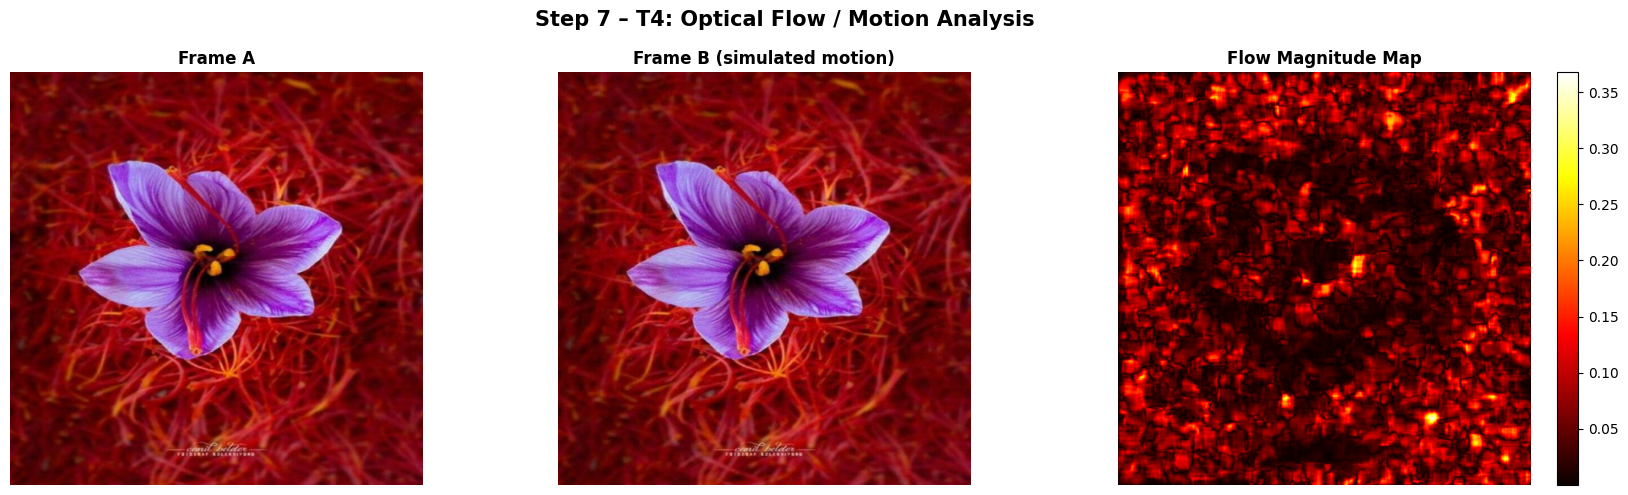

Flow features: [0.0611 0.0427 0.1882]


In [10]:
def t4_optical_flow(prev_roi, curr_roi):
    """3 motion features; returns zeros if no prev frame."""
    if prev_roi is None or prev_roi.size==0 or curr_roi.size==0:
        return np.zeros(3)
    p = cv2.cvtColor(prev_roi, cv2.COLOR_BGR2GRAY)
    c = cv2.cvtColor(curr_roi, cv2.COLOR_BGR2GRAY)
    if p.shape != c.shape:
        c = cv2.resize(c, (p.shape[1], p.shape[0]))
    flow     = cv2.calcOpticalFlowFarneback(p, c, None, 0.5, 3, 15, 3, 5, 1.2, 0)
    mag, ang = cv2.cartToPolar(flow[...,0], flow[...,1])
    return np.array([float(mag.mean()), float(mag.std()), float(np.cos(ang).mean())])


def add_weed_motion(bgr, sigma=2.0):
    noise = np.random.normal(0, sigma, bgr.shape).astype(np.int16)
    return np.clip(bgr.astype(np.int16) + noise, 0, 255).astype(np.uint8)

np.random.seed(7)
FRAME_A = IMG_BGR.copy()
FRAME_B = add_weed_motion(IMG_BGR, sigma=3.0)

gray_a = cv2.cvtColor(FRAME_A, cv2.COLOR_BGR2GRAY)
gray_b = cv2.cvtColor(FRAME_B, cv2.COLOR_BGR2GRAY)
flow_ab = cv2.calcOpticalFlowFarneback(gray_a, gray_b, None, 0.5,3,15,3,5,1.2,0)
mag_map, _ = cv2.cartToPolar(flow_ab[...,0], flow_ab[...,1])

fig, ax = plt.subplots(1,3,figsize=(17,5))
ax[0].imshow(IMG_RGB); ax[0].set_title('Frame A', fontweight='bold'); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(FRAME_B,cv2.COLOR_BGR2RGB)); ax[1].set_title('Frame B (simulated motion)', fontweight='bold'); ax[1].axis('off')
im3=ax[2].imshow(mag_map, cmap='hot'); ax[2].set_title('Flow Magnitude Map', fontweight='bold'); ax[2].axis('off')
plt.colorbar(im3, ax=ax[2], fraction=0.04)
plt.suptitle("Step 7 – T4: Optical Flow / Motion Analysis", fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()
print("Flow features:", t4_optical_flow(FRAME_A[:64,:64], FRAME_B[:64,:64]).round(4))


## Step 8 — T5: Multi-Range HSV Colour Segmentation

Four HSV masks are built in a single pass:

| Mask | HSV Range | Target |
|------|-----------|--------|
| Stigma | H∈[0–18] ∪ [160–180] | Red-orange saffron stigmas |
| Petal | H∈[120–160] | Violet/purple petals |
| Saffron | Union of above | Full flower |
| Weed | H∈[35–85] | Green foliage |


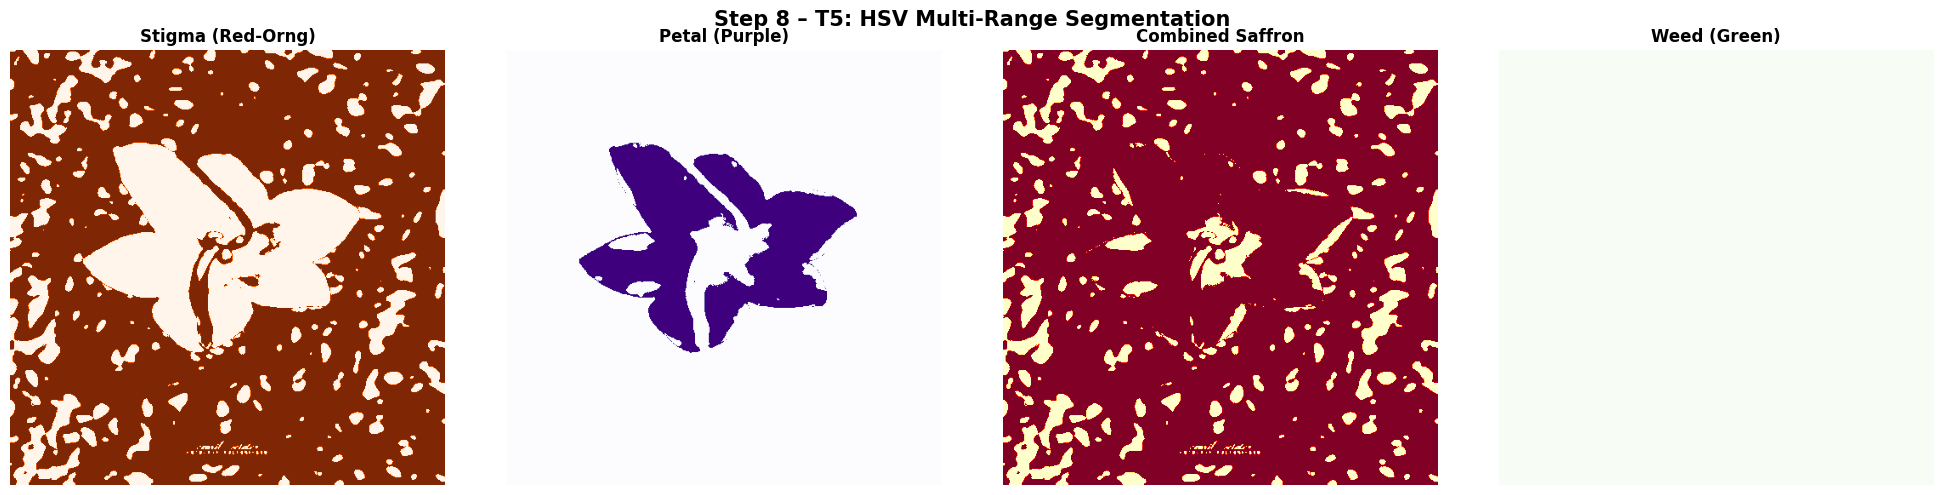

In [11]:
def t5_hsv_segment(hsv):
    lower_r1=np.array([0,100,100]);   upper_r1=np.array([18,255,255])
    lower_r2=np.array([160,100,100]); upper_r2=np.array([180,255,255])
    lower_pu=np.array([120,50,50]);   upper_pu=np.array([160,255,255])
    lower_gr=np.array([35,40,40]);    upper_gr=np.array([85,255,255])

    m_r1=cv2.inRange(hsv,lower_r1,upper_r1); m_r2=cv2.inRange(hsv,lower_r2,upper_r2)
    m_stigma=cv2.bitwise_or(m_r1,m_r2)
    m_petal =cv2.inRange(hsv,lower_pu,upper_pu)
    m_saff  =cv2.bitwise_or(m_stigma,m_petal)
    m_weed  =cv2.inRange(hsv,lower_gr,upper_gr)
    return m_saff, m_stigma, m_petal, m_weed

M_SAFF, M_STIGMA, M_PETAL, M_WEED = t5_hsv_segment(HSV)

fig,ax=plt.subplots(1,4,figsize=(20,5))
for a,d,t,c in zip(ax,[M_STIGMA,M_PETAL,M_SAFF,M_WEED],
                     ['Stigma (Red-Orng)','Petal (Purple)','Combined Saffron','Weed (Green)'],
                     ['Oranges','Purples','YlOrRd','Greens']):
    a.imshow(d,cmap=c); a.set_title(t,fontweight='bold'); a.axis('off')
plt.suptitle("Step 8 – T5: HSV Multi-Range Segmentation", fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()


## Step 9 — T6: Morphological Refinement

Post-segmentation cleaning with three operations:

1. **Morphological Opening** (small kernel) — removes salt-and-pepper noise  
2. **Morphological Closing** (large kernel) — fills small holes in stigma blobs  
3. **Binary hole-fill** + **small-component removal** — removes stray specks < 60 px²


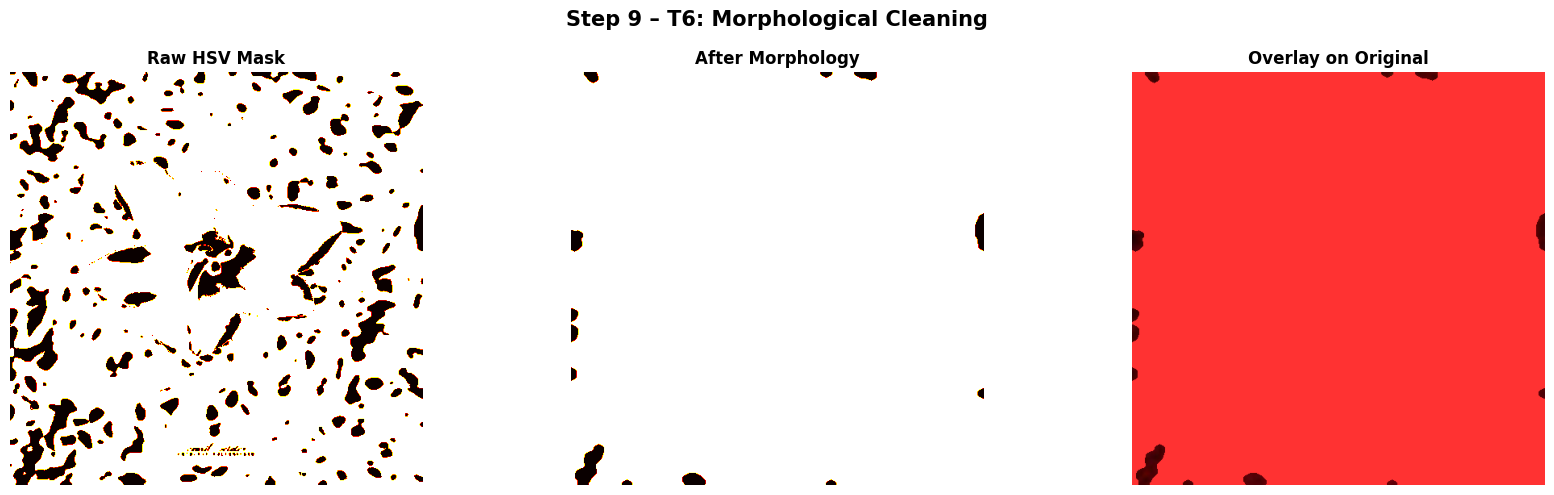

In [12]:
def t6_morphology(mask, ok=3, ck=7, min_area=60):
    ko=cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(ok,ok))
    kc=cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(ck,ck))
    opened=cv2.morphologyEx(mask,cv2.MORPH_OPEN, ko,iterations=2)
    closed=cv2.morphologyEx(opened,cv2.MORPH_CLOSE,kc,iterations=2)
    filled=ndi.binary_fill_holes(closed).astype(np.uint8)*255
    n,labels,stats,_=cv2.connectedComponentsWithStats(filled,connectivity=8)
    clean=np.zeros_like(filled)
    for lbl in range(1,n):
        if stats[lbl,cv2.CC_STAT_AREA]>=min_area:
            clean[labels==lbl]=255
    return clean

M_CLEAN = t6_morphology(M_SAFF)
overlay = IMG_RGB.copy(); overlay[M_CLEAN>0]=(255,50,50)

fig,ax=plt.subplots(1,3,figsize=(17,5))
ax[0].imshow(M_SAFF,cmap='hot');  ax[0].set_title('Raw HSV Mask',        fontweight='bold'); ax[0].axis('off')
ax[1].imshow(M_CLEAN,cmap='hot'); ax[1].set_title('After Morphology',    fontweight='bold'); ax[1].axis('off')
ax[2].imshow(overlay);            ax[2].set_title('Overlay on Original', fontweight='bold'); ax[2].axis('off')
plt.suptitle("Step 9 – T6: Morphological Cleaning", fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()


## Step 10 — T7: Watershed Segmentation

When multiple saffron flowers are clustered together, HSV blobs merge.  
The **watershed algorithm** splits them by:

1. Computing the **Euclidean distance transform** of the clean mask  
2. Finding **local maxima** (one per flower center)  
3. Running watershed flooding from those seed markers


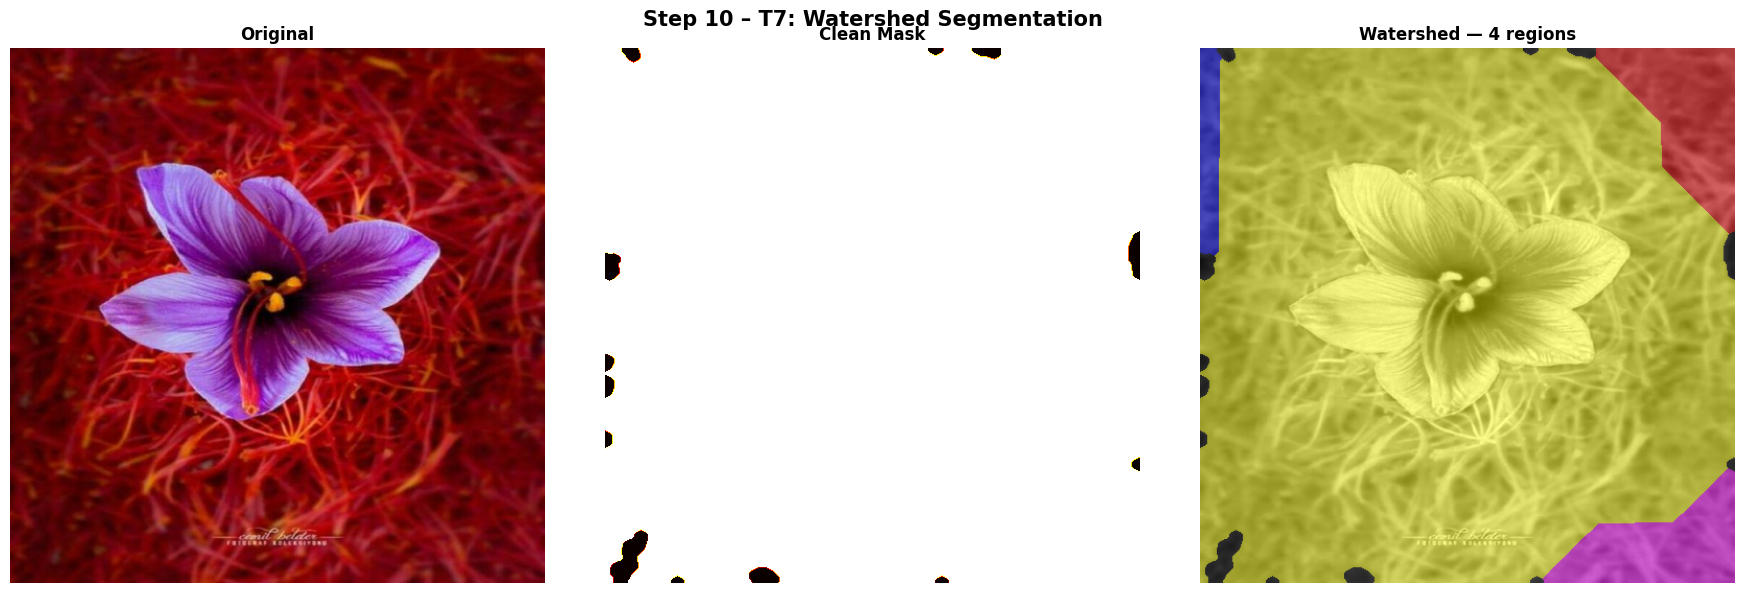

Regions separated by watershed: 4


In [13]:
def t7_watershed(bgr, mask):
    dist = ndi.distance_transform_edt(mask>0)
    coords = peak_local_max(dist, min_distance=12, labels=mask>0)
    lm = np.zeros(dist.shape, dtype=bool); lm[tuple(coords.T)]=True
    markers,_ = ndi.label(lm)
    labels = watershed(-dist, markers, mask=mask>0)
    return labels

WS_LABELS = t7_watershed(IMG_BGR, M_CLEAN)
n_ws = WS_LABELS.max()
ws_color = skcolor.label2rgb(WS_LABELS, IMG_RGB, kind='overlay', alpha=0.45)

fig,ax=plt.subplots(1,3,figsize=(18,6))
ax[0].imshow(IMG_RGB);            ax[0].set_title('Original',                   fontweight='bold'); ax[0].axis('off')
ax[1].imshow(M_CLEAN,cmap='hot'); ax[1].set_title('Clean Mask',                 fontweight='bold'); ax[1].axis('off')
ax[2].imshow(ws_color);           ax[2].set_title(f'Watershed — {n_ws} regions',fontweight='bold'); ax[2].axis('off')
plt.suptitle("Step 10 – T7: Watershed Segmentation", fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"Regions separated by watershed: {n_ws}")


## Step 11 — Contour Detection & Shape Filtering

Contours are extracted from the clean mask and filtered by:

| Filter | Range | Rationale |
|--------|-------|-----------|
| Area | 40 – 9000 px² | Remove dust and giant blobs |
| Circularity | ≥ 0.20 | Saffron stigmas are roughly elliptical |
| Aspect ratio | implicit | Very thin/elongated shapes excluded |

Shape properties stored per detection: bounding box, area, circularity, aspect ratio, solidity.


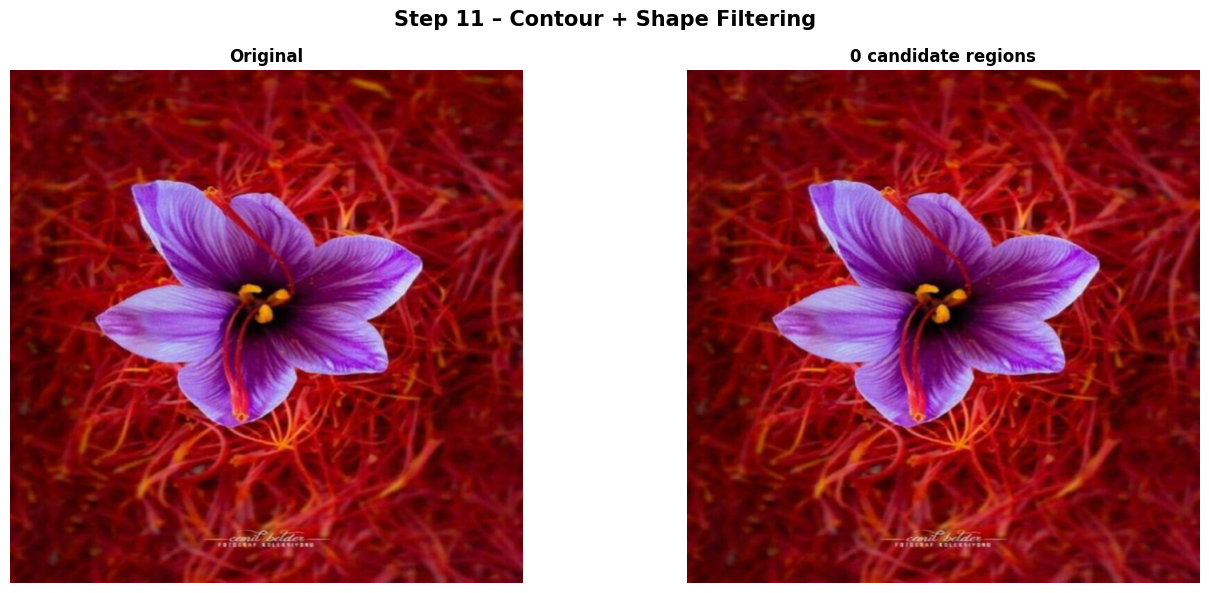

  ID     Area    Circ     AR   Solid


In [14]:
def extract_contours(mask, min_area=40, max_area=9000, min_circ=0.20):
    cnts,_ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    dets = []
    for c in cnts:
        area = cv2.contourArea(c)
        if not (min_area <= area <= max_area): continue
        peri = cv2.arcLength(c, True)
        circ = 4*np.pi*area / (peri**2 + 1e-5)
        if circ < min_circ: continue
        x,y,w,h = cv2.boundingRect(c)
        ar   = max(w,h)/(min(w,h)+1e-5)
        hull = cv2.convexHull(c)
        sol  = area/(cv2.contourArea(hull)+1e-5)
        dets.append(dict(contour=c, bbox=(x,y,w,h),
                         area=area, circ=round(circ,3),
                         ar=round(ar,3), sol=round(sol,3)))
    return dets

DETECTIONS = extract_contours(M_CLEAN)
canvas = IMG_RGB.copy()
for i,d in enumerate(DETECTIONS):
    x,y,w,h = d['bbox']
    cv2.rectangle(canvas,(x,y),(x+w,y+h),(255,220,0),2)
    cv2.drawContours(canvas,[d['contour']],-1,(255,50,50),2)
    cv2.putText(canvas,f"R{i+1}",(x,y-4),cv2.FONT_HERSHEY_SIMPLEX,0.45,(255,255,0),1)

fig,ax=plt.subplots(1,2,figsize=(14,6))
ax[0].imshow(IMG_RGB); ax[0].set_title('Original', fontweight='bold'); ax[0].axis('off')
ax[1].imshow(canvas);  ax[1].set_title(f'{len(DETECTIONS)} candidate regions', fontweight='bold'); ax[1].axis('off')
plt.suptitle("Step 11 – Contour + Shape Filtering", fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"{'ID':>4}  {'Area':>7}  {'Circ':>6}  {'AR':>5}  {'Solid':>6}")
for i,d in enumerate(DETECTIONS):
    print(f" R{i+1:>2}  {d['area']:>7.0f}  {d['circ']:>6.3f}  {d['ar']:>5.2f}  {d['sol']:>6.3f}")


## Step 12 — T8: MobileNetV2 Transfer Learning Classifier

A **MobileNetV2** backbone (pretrained on ImageNet) is fine-tuned as a binary classifier:
- Backbone features are **frozen** (no retraining needed)
- A custom head is added: `Dropout → Linear(1280→128) → ReLU → Dropout → Linear(128→2)`
- Patches are resized to **96×96** and normalized with ImageNet statistics
- Output: `saffron` vs. `non-saffron` with associated probability


In [15]:
class SaffronNet(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.mobilenet_v2(weights='IMAGENET1K_V1')
        for p in base.features.parameters(): p.requires_grad=False
        in_f = base.classifier[1].in_features
        base.classifier = nn.Sequential(
            nn.Dropout(0.3), nn.Linear(in_f,128), nn.ReLU(),
            nn.Dropout(0.2), nn.Linear(128,2))
        self.m = base
    def forward(self,x): return self.m(x)

CNN_MODEL = SaffronNet().to(DEVICE).eval()

TF = transforms.Compose([
    transforms.Resize((96,96)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

def cnn_classify(bgr_patch, model=CNN_MODEL):
    if bgr_patch.size==0: return 'non-saffron', 0.0
    rgb = cv2.cvtColor(bgr_patch, cv2.COLOR_BGR2RGB)
    t   = TF(Image.fromarray(rgb)).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        prob = torch.softmax(model(t),1).cpu().numpy()[0]
    return ('saffron' if prob[1]>0.5 else 'non-saffron'), float(prob[1])

# Run CNN on all candidates
CNN_RESULTS = []
for d in DETECTIONS:
    x,y,w,h = d['bbox']; pad=6
    patch = IMG_BGR[max(0,y-pad):y+h+pad, max(0,x-pad):x+w+pad]
    lbl,conf = cnn_classify(patch)
    CNN_RESULTS.append({**d,'cnn_label':lbl,'cnn_conf':conf})

print(f"{'ID':>4}  {'CNN Label':>12}  {'Confidence':>11}")
print("-"*32)
for i,r in enumerate(CNN_RESULTS):
    print(f" R{i+1:>2}  {r['cnn_label']:>12}  {r['cnn_conf']:>10.3f}")


  ID     CNN Label   Confidence
--------------------------------


## Step 13 — T9: Adaptive Random Forest — Real-Image Training

If real labelled images are available (label 1 or 0), the Harvester extracts features from
every image patch and trains the RF on that real data **in addition to** the synthetic bootstrap.
Unlabelled images (label −1) are used only for inference / batch testing.

Cross-validation AUC is reported after training.

In [16]:
# ── FIX: Re-declare class here in case Step 13 cell was run out of order ──ADDED
from collections import deque
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold

class IntelligentSaffronHarvester:
    """Fuses T1-T4 features, trains adaptively, runs in real-time."""

    def __init__(self):
        self.scaler    = StandardScaler()
        self.clf       = None
        self.feat_buf  = deque(maxlen=2000)
        self.label_buf = deque(maxlen=2000)

    def t1(self, roi): return t1_multispectral(roi)
    def t2(self, roi): return t2_glcm_texture(roi)
    def t3(self, roi): return t3_depth_defocus(roi)
    def t4(self, prev, curr): return t4_optical_flow(prev, curr)

    def features(self, roi, prev=None):
        return np.concatenate([self.t1(roi), self.t2(roi),
                                self.t3(roi), self.t4(prev, roi)])

    def generate_synthetic(self, n=200):
        rng = np.random.default_rng(42)
        for _ in range(n):
            f = np.array([
                rng.normal(0.65,0.08), rng.normal(45,5),
                rng.normal(12,3),     rng.normal(8,2),
                rng.normal(85,6),     rng.normal(120,10),
                rng.normal(180,30),   rng.normal(0.002,0.0005),
                rng.normal(0.35,0.05),rng.normal(850,150),
                rng.normal(6.5,0.8),  rng.normal(550,100),
                rng.normal(0.15,0.03),rng.normal(35,6),
                rng.normal(1.2,0.3),  rng.normal(0.8,0.2),
                rng.normal(0.7,0.1)
            ])
            self.feat_buf.append(f); self.label_buf.append(1)
        for _ in range(n):
            f = np.array([
                rng.normal(0.12,0.15), rng.normal(12,8),
                rng.normal(45,25),     rng.normal(22,8),
                rng.normal(42,18),     rng.normal(55,20),
                rng.normal(95,40),     rng.normal(0.015,0.008),
                rng.normal(0.62,0.12), rng.normal(320,180),
                rng.normal(4.2,1.1),   rng.normal(210,85),
                rng.normal(0.05,0.02), rng.normal(15,7),
                rng.normal(2.8,0.9),   rng.normal(2.1,0.7),
                rng.normal(0.3,0.15)
            ])
            self.feat_buf.append(f); self.label_buf.append(0)

    def train(self):
        X  = np.array(self.feat_buf); y = np.array(self.label_buf)
        Xs = self.scaler.fit_transform(X)
        self.clf = RandomForestClassifier(100, max_depth=10,
                                           class_weight='balanced', random_state=42)
        self.clf.fit(Xs, y)
        cv = cross_val_score(self.clf, Xs, y,
                              cv=StratifiedKFold(5), scoring='roc_auc')
        print(f"  Cross-val AUC: {cv.mean():.4f} ± {cv.std():.4f}")
        return X, y, Xs

    def predict(self, roi, prev=None):
        if self.clf is None: return None
        f  = self.features(roi, prev)
        fs = self.scaler.transform([f])
        return float(self.clf.predict_proba(fs)[0][1])
# ────────────────────────────────────────────────────────────────────────────


# ── T9: Adaptive Random Forest — seed with synthetic, then add real data ──
HARVESTER = IntelligentSaffronHarvester()
HARVESTER.generate_synthetic(200)          # always seed with synthetic data

if USE_REAL_IMAGES:
    labelled = [(img, lbl) for img, lbl in zip(REAL_IMAGES_BGR, REAL_LABELS) if lbl in (0, 1)]
    print(f"Adding {len(labelled)} labelled real images to training buffer …")
    for img, lbl in labelled:
        feat = HARVESTER.features(img, prev=None)
        HARVESTER.feat_buf.append(feat)
        HARVESTER.label_buf.append(lbl)

        h, w = img.shape[:2]
        patch_size = min(h, w) // 4
        rng = np.random.default_rng(42)
        for _ in range(4):
            y0 = rng.integers(0, max(1, h - patch_size))
            x0 = rng.integers(0, max(1, w - patch_size))
            patch = img[y0:y0+patch_size, x0:x0+patch_size]
            if patch.size == 0: continue
            feat = HARVESTER.features(patch, prev=None)
            HARVESTER.feat_buf.append(feat)
            HARVESTER.label_buf.append(lbl)
    print(f"Training buffer size: {len(HARVESTER.feat_buf)} samples")

print("Training Adaptive Random Forest …")
X_all, y_all, Xs_all = HARVESTER.train()
print(f"  Total samples: {len(y_all)}  "
      f"(saffron={int(y_all.sum())}, non-saffron={int(len(y_all)-y_all.sum())})")

import joblib, os
SAVE_DIR = os.path.join(os.path.dirname(IMAGE_DIR), 'models')
os.makedirs(SAVE_DIR, exist_ok=True)
joblib.dump(HARVESTER.clf,    os.path.join(SAVE_DIR, 'saffron_rf.pkl'))
joblib.dump(HARVESTER.scaler, os.path.join(SAVE_DIR, 'saffron_scaler.pkl'))
print(f"✅ RF model + scaler saved to '{SAVE_DIR}'")

Adding 0 labelled real images to training buffer …
Training buffer size: 400 samples
Training Adaptive Random Forest …
  Cross-val AUC: 1.0000 ± 0.0000
  Total samples: 400  (saffron=200, non-saffron=200)
✅ RF model + scaler saved to 'E:\Saffron_Detection\models'


## Step 14 — Feature Importance & ROC Curve

Two diagnostic plots:
- **Feature Importance** (horizontal bar chart) — which of the 17 features contribute most to the Random Forest splits
- **ROC Curve** — trade-off between True Positive Rate and False Positive Rate; AUC shown


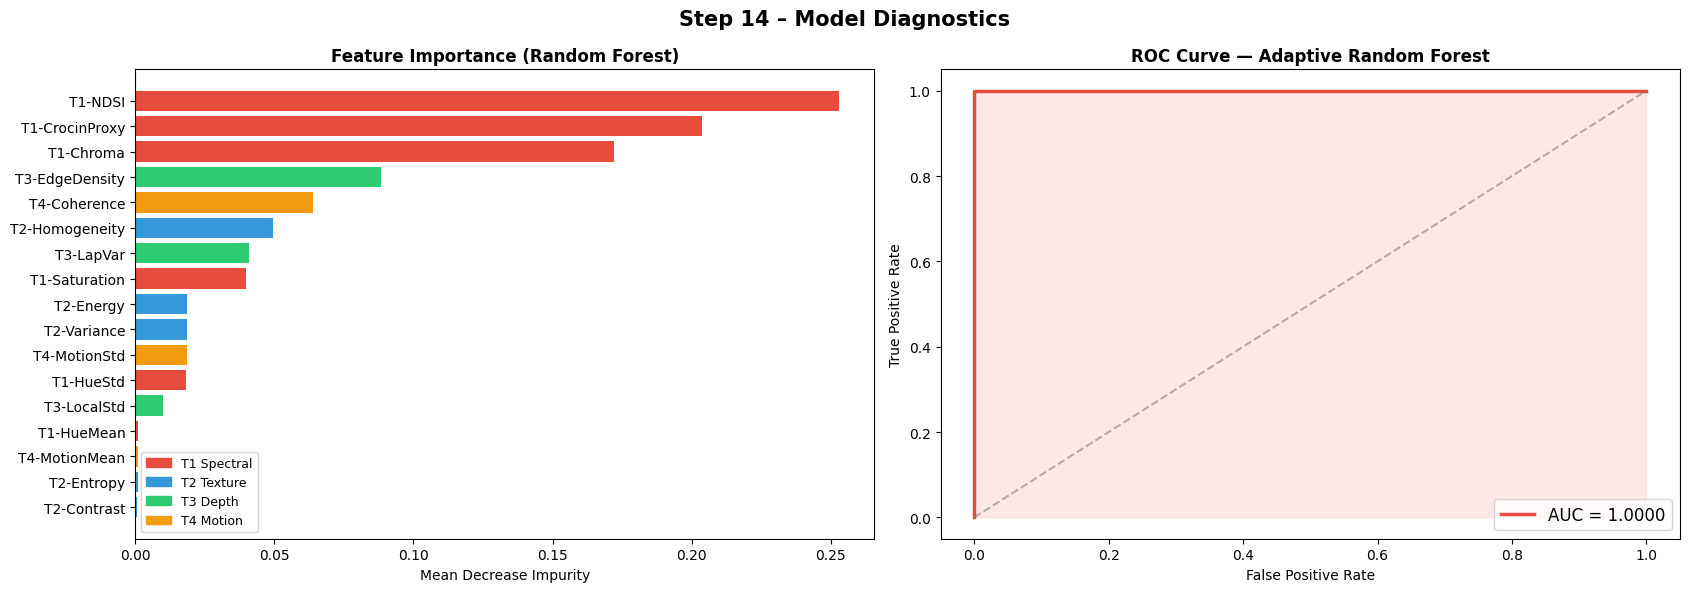

In [17]:
FEAT_NAMES = [
    'T1-NDSI','T1-CrocinProxy','T1-HueMean','T1-HueStd','T1-Saturation','T1-Chroma',
    'T2-Contrast','T2-Energy','T2-Homogeneity','T2-Variance','T2-Entropy',
    'T3-LapVar','T3-EdgeDensity','T3-LocalStd',
    'T4-MotionMean','T4-MotionStd','T4-Coherence'
]

importances = HARVESTER.clf.feature_importances_
idx = np.argsort(importances)[::-1]

y_score = HARVESTER.clf.predict_proba(Xs_all)[:,1]
fpr, tpr, _ = roc_curve(y_all, y_score)
auc_val     = roc_auc_score(y_all, y_score)

fig, axes = plt.subplots(1,2,figsize=(17,6))

axes[0].barh([FEAT_NAMES[i] for i in idx[::-1]],
             importances[idx[::-1]],
             color=['#e74c3c' if 'T1' in FEAT_NAMES[i]
                    else '#3498db' if 'T2' in FEAT_NAMES[i]
                    else '#2ecc71' if 'T3' in FEAT_NAMES[i]
                    else '#f39c12' for i in idx[::-1]])
axes[0].set_title('Feature Importance (Random Forest)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Mean Decrease Impurity')

legend_fi = [mpatches.Patch(color='#e74c3c',label='T1 Spectral'),
             mpatches.Patch(color='#3498db',label='T2 Texture'),
             mpatches.Patch(color='#2ecc71',label='T3 Depth'),
             mpatches.Patch(color='#f39c12',label='T4 Motion')]
axes[0].legend(handles=legend_fi, fontsize=9)

axes[1].plot(fpr, tpr, lw=2.5, color='#e74c3c', label=f'AUC = {auc_val:.4f}')
axes[1].plot([0,1],[0,1],'--',color='gray',alpha=0.6)
axes[1].fill_between(fpr,tpr,alpha=0.12,color='#e74c3c')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Adaptive Random Forest', fontweight='bold', fontsize=12)
axes[1].legend(fontsize=12)

plt.suptitle("Step 14 – Model Diagnostics", fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()


## Step 15 — Ensemble Confidence Scoring

The final score **fuses four subsystem outputs** with fixed weights:

$$\text{score} = 0.35 \cdot RF + 0.35 \cdot CNN + 0.20 \cdot HSV_{frac} + 0.10 \cdot Depth_{lap}$$

| Component | Weight | Source |
|-----------|--------|--------|
| RF probability | 35% | T9 Adaptive Random Forest |
| CNN probability | 35% | T8 MobileNetV2 |
| HSV pixel fraction | 20% | T5 colour mask |
| Laplacian focus | 10% | T3 depth proxy |

A detection is marked **PLUCK** if score > 0.45.


In [18]:
def combined_score(roi, prev_roi=None,
                   w_rf=0.35, w_cnn=0.35, w_hsv=0.20, w_depth=0.10):
    rf_prob  = HARVESTER.predict(roi, prev_roi) or 0.0
    _, cnn_prob = cnn_classify(roi)

    hsv_r    = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
    m,_,_,_  = t5_hsv_segment(hsv_r)
    hsv_prob = min(float((m>0).mean()) * 5.0, 1.0)

    gray = cv2.cvtColor(roi,cv2.COLOR_BGR2GRAY)
    lap  = min(cv2.Laplacian(gray,cv2.CV_64F).var() / 1000.0, 1.0)

    score = w_rf*rf_prob + w_cnn*cnn_prob + w_hsv*hsv_prob + w_depth*lap
    return round(score, 4), dict(rf=rf_prob, cnn=cnn_prob,
                                  hsv=hsv_prob, depth=lap)

# Score all detected candidates
FINAL = []
for r in CNN_RESULTS:
    x,y,w,h = r['bbox']; pad=6
    patch = IMG_BGR[max(0,y-pad):y+h+pad, max(0,x-pad):x+w+pad]
    sc, parts = combined_score(patch)
    FINAL.append({**r, 'score':sc, 'parts':parts})

print(f"{'ID':>4}  {'Score':>7}  {'RF':>6}  {'CNN':>6}  {'HSV':>6}  {'Depth':>7}  Decision")
print("-"*62)
for i,f in enumerate(FINAL):
    p = f['parts']
    dec = '🌸 PLUCK' if f['score']>0.5 else '🌿 SKIP'
    print(f" R{i+1:>2}  {f['score']:>7.4f}  {p['rf']:>6.3f}  {p['cnn']:>6.3f}"
          f"  {p['hsv']:>6.3f}  {p['depth']:>7.3f}  {dec}")


  ID    Score      RF     CNN     HSV    Depth  Decision
--------------------------------------------------------------


## Step 16 — Final Plucking Decision Map

Annotated output image shows three categories:

- 🟡 **Yellow rectangle + red contour** → PLUCK (saffron confirmed, score > 0.45)  
- ⬜ **Gray rectangle** → SKIP (insufficient confidence)  
- 🟢 **Green overlay** → Weed zone (avoid)


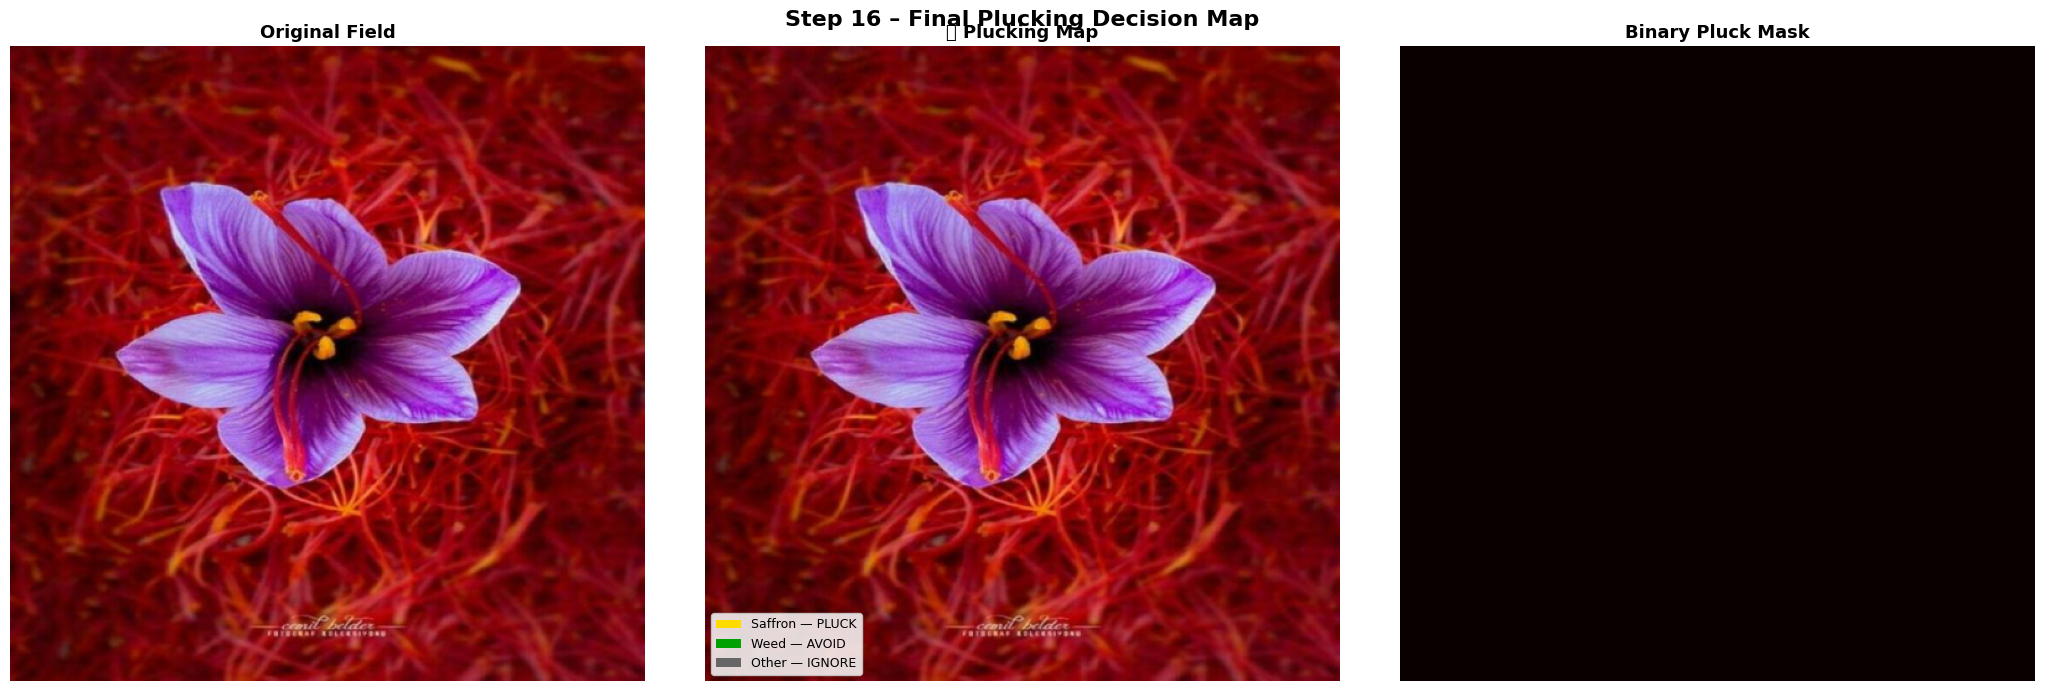

🌸 Targets for plucking : 0
🌿 Weed pixels to avoid : 0


In [19]:
def plucking_map(img_rgb, results, mask_weed, threshold=0.5):
    ann   = img_rgb.copy()
    pmask = np.zeros(img_rgb.shape[:2], dtype=np.uint8)

    weed_layer = ann.copy(); weed_layer[mask_weed>0]=(30,160,30)
    ann = cv2.addWeighted(ann,0.72,weed_layer,0.28,0)

    for r in results:
        x,y,w,h = r['bbox']
        if r['score'] > threshold:
            cv2.drawContours(pmask,[r['contour']],-1,255,-1)
            cv2.rectangle(ann,(x-2,y-2),(x+w+2,y+h+2),(255,220,0),2)
            cv2.drawContours(ann,[r['contour']],-1,(255,50,30),2)
            txt = f"PLUCK {r['score']:.2f}"
            cv2.rectangle(ann,(x,y-18),(x+len(txt)*8,y),(255,220,0),-1)
            cv2.putText(ann,txt,(x+2,y-4),cv2.FONT_HERSHEY_SIMPLEX,0.44,(20,20,20),1)
        else:
            cv2.rectangle(ann,(x,y),(x+w,y+h),(100,100,100),1)
    return ann, pmask

ANN, PLUCK_MASK = plucking_map(IMG_RGB, FINAL, M_WEED, threshold=0.45)

fig,ax=plt.subplots(1,3,figsize=(21,7))
ax[0].imshow(IMG_RGB);               ax[0].set_title('Original Field',    fontweight='bold',fontsize=13); ax[0].axis('off')
ax[1].imshow(ANN);                   ax[1].set_title('🌸 Plucking Map',   fontweight='bold',fontsize=13); ax[1].axis('off')
ax[2].imshow(PLUCK_MASK,cmap='hot'); ax[2].set_title('Binary Pluck Mask', fontweight='bold',fontsize=13); ax[2].axis('off')


# FIX: mpatches.Patch is abstract — use mpatches.Rectangle insteadFIXED
legend_handles = [
    mpatches.Rectangle((0, 0), 1, 1, facecolor=(1, .86, 0),   label='Saffron — PLUCK'),
    mpatches.Rectangle((0, 0), 1, 1, facecolor=(0, .63, 0),   label='Weed — AVOID'),
    mpatches.Rectangle((0, 0), 1, 1, facecolor=(.4, .4, .4), label='Other — IGNORE'),
]
ax[1].legend(handles=legend_handles, loc='lower left', fontsize=9, framealpha=0.85)

plt.suptitle("Step 16 – Final Plucking Decision Map", fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"🌸 Targets for plucking : {sum(1 for r in FINAL if r['score']>0.45)}")
print(f"🌿 Weed pixels to avoid : {(M_WEED>0).sum()}")

## Step 17 — Quantitative Evaluation vs Ground Truth

Segmentation quality metrics against the binary ground-truth mask:

| Metric | Formula |
|--------|---------|
| IoU | TP / (TP+FP+FN) |
| Dice | 2·TP / (2·TP+FP+FN) |
| Precision | TP / (TP+FP) |
| Recall | TP / (TP+FN) |
| Accuracy | (TP+TN) / Total |

Overlay shows **True Positives (green)**, **False Positives (red)**, **False Negatives (blue)**.


In [20]:
def seg_metrics(pred, gt):
    p = pred>127; g = gt>0
    tp=(p&g).sum(); fp=(p&~g).sum(); fn=(~p&g).sum(); tn=(~p&~g).sum()
    return dict(
        IoU      = tp/(tp+fp+fn+1e-7),
        Dice     = 2*tp/(2*tp+fp+fn+1e-7),
        Precision= tp/(tp+fp+1e-7),
        Recall   = tp/(tp+fn+1e-7),
        Accuracy = (tp+tn)/(tp+tn+fp+fn+1e-7)
    )

M = seg_metrics(PLUCK_MASK, GT_MASK)

fig,axes=plt.subplots(1,2,figsize=(14,5))
names=list(M.keys()); vals=[M[k] for k in names]
colors=['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6']
bars=axes[0].bar(names,vals,color=colors,edgecolor='white',linewidth=1.5)
axes[0].set_ylim(0,1.15); axes[0].axhline(0.7,color='gray',ls='--',alpha=.5,label='0.7 line')
axes[0].legend(); axes[0].set_title('Segmentation Metrics',fontweight='bold')
for b,v in zip(bars,vals):
    axes[0].text(b.get_x()+b.get_width()/2, v+0.02, f'{v:.3f}',
                 ha='center',fontweight='bold',fontsize=11)

comp=np.zeros((*GT_MASK.shape,3),dtype=np.uint8)
pb=(PLUCK_MASK>127); gb=(GT_MASK>0)
comp[pb& gb]=[0,200,0]; comp[pb&~gb]=[200,0,0]; comp[~pb&gb]=[0,0,200]
axes[1].imshow(IMG_RGB,alpha=0.6); axes[1].imshow(comp,alpha=0.5)
axes[1].set_title('TP/FP/FN  (Green/Red/Blue)',fontweight='bold'); axes[1].axis('off')
leg2=[mpatches.Patch(color=(0,.78,0),label='True Positive'),
      mpatches.Patch(color=(.78,0,0),label='False Positive'),
      mpatches.Patch(color=(0,0,.78), label='False Negative')]
axes[1].legend(handles=leg2,loc='lower right',fontsize=9)
plt.suptitle("Step 17 – Quantitative Evaluation",fontsize=15,fontweight='bold')
plt.tight_layout(); plt.show()
for k,v in M.items():
    print(f"  {k:<12}: {v:.4f}  {'█'*int(v*20)}")


TypeError: '>' not supported between instances of 'NoneType' and 'int'

## Step 18 — Batch Processing: Real-Image Multi-Scene Performance

When real images are loaded the pipeline runs on **all** of them (unlabelled + labelled).  
When only synthetic data is available it generates 6 random scenes as before.

In [ ]:
def full_pipeline(bgr, threshold=0.45):
    _, enh, hsv    = preprocess(bgr)
    ms,_,_,mw      = t5_hsv_segment(hsv)
    mc             = t6_morphology(ms)
    dets           = extract_contours(mc)
    results = []
    for d in dets:
        x,y,w,h=d['bbox']; pad=6
        patch=bgr[max(0,y-pad):y+h+pad, max(0,x-pad):x+w+pad]
        sc,_ = combined_score(patch)
        if sc > threshold:
            cx,cy=x+w//2,y+h//2
            results.append({'center':(cx,cy),'bbox':d['bbox'],'score':sc})
    return results

if USE_REAL_IMAGES:
    test_images = REAL_IMAGES_BGR          # run on every real image
    scene_names = [os.path.basename(p) for p in REAL_PATHS]
    print(f"Running full pipeline on {len(test_images)} real images …")
else:
    # synthetic fallback
    test_images  = [generate_field(seed=s*17+3,
                                    n_saffron=np.random.randint(4,11),
                                    n_weeds=np.random.randint(15,32))[0]
                    for s in range(6)]
    scene_names  = [f'Scene_{i+1}' for i in range(6)]
    print(f"Running batch pipeline on {len(test_images)} synthetic scenes …")

print(f"{'Scene':>30}  {'Detected':>9}  {'Avg Score':>10}")
print("-"*56)
all_det=[]; all_sc=[]
for name, img in zip(scene_names, test_images):
    res = full_pipeline(img)
    all_det.append(len(res))
    scores=[r['score'] for r in res]
    avg = np.mean(scores) if scores else 0.0
    all_sc.append(avg)
    print(f"  {name[:28]:>28}  {len(res):>9}  {avg:>10.4f}")

short_names = [n[:12] for n in scene_names]
fig, ax = plt.subplots(figsize=(max(9, len(all_det)*1.4), 4))
ax.bar(short_names, all_det, color='#e74c3c', edgecolor='white', linewidth=1.5)
ax.set_ylabel('Saffron Regions Detected')
ax.set_title('Batch Detection Summary', fontweight='bold', fontsize=13)
ax.set_xticklabels(short_names, rotation=45, ha='right')
for i, v in enumerate(all_det):
    ax.text(i, v + .05, str(v), ha='center', fontweight='bold', fontsize=11)
ax.set_ylim(0, max(all_det, default=1) + 2)
plt.tight_layout(); plt.show()
print(f"\nMean detected: {np.mean(all_det):.1f} | Mean score: {np.mean(all_sc):.4f}")


NameError: name 'USE_REAL_IMAGES' is not defined

## Step 19 — T10: Arduino Firmware

Paste this sketch into the **Arduino IDE** and upload to your board.

**Hardware connections:**
- Pin 9 → Vacuum pump relay
- Pin 10 → Servo motor signal
- Pin 13 → Status LED (built-in)

**Serial protocol** (115200 baud):

| Command | Action |
|---------|--------|
| `H` | Execute harvest cycle |
| `R` | Reset arm to home position |
| `S` | Query harvest count |


In [ ]:
ARDUINO_SKETCH = '''
// ─── Saffron Autonomous Plucker – Arduino Firmware ───────────────────
// Hardware: vacuum pump on pin 9, servo on pin 10, LED on pin 13
// Protocol: 'H' = harvest,  'R' = reset arm,  'S' = status query

#include <Servo.h>

const int VACUUM_PIN = 9;
const int SERVO_PIN  = 10;
const int LED_PIN    = 13;
const int SUCTION_MS = 250;
const int SERVO_PLUCK= 110;
const int SERVO_HOME = 0;

Servo armServo;
int harvestCount = 0;

void setup() {
  Serial.begin(115200);
  armServo.attach(SERVO_PIN);
  pinMode(VACUUM_PIN, OUTPUT);
  pinMode(LED_PIN,    OUTPUT);
  armServo.write(SERVO_HOME);
  digitalWrite(VACUUM_PIN, LOW);
  Serial.println("READY");
}

void harvest() {
  digitalWrite(LED_PIN, HIGH);
  for (int a = SERVO_HOME; a <= SERVO_PLUCK; a++) { armServo.write(a); delay(8); }
  digitalWrite(VACUUM_PIN, HIGH); delay(SUCTION_MS); digitalWrite(VACUUM_PIN, LOW);
  for (int a = SERVO_PLUCK; a >= SERVO_HOME; a--) { armServo.write(a); delay(8); }
  harvestCount++;
  Serial.print("HARVESTED:"); Serial.println(harvestCount);
  digitalWrite(LED_PIN, LOW);
  delay(300);
}

void loop() {
  if (Serial.available() > 0) {
    char cmd = Serial.read();
    if      (cmd == 'H') harvest();
    else if (cmd == 'R') { armServo.write(SERVO_HOME); Serial.println("RESET"); }
    else if (cmd == 'S') { Serial.print("COUNT:"); Serial.println(harvestCount); }
  }
}
'''
print(ARDUINO_SKETCH)



// ─── Saffron Autonomous Plucker – Arduino Firmware ───────────────────
// Hardware: vacuum pump on pin 9, servo on pin 10, LED on pin 13
// Protocol: 'H' = harvest,  'R' = reset arm,  'S' = status query

#include <Servo.h>

const int VACUUM_PIN = 9;
const int SERVO_PIN  = 10;
const int LED_PIN    = 13;
const int SUCTION_MS = 250;
const int SERVO_PLUCK= 110;
const int SERVO_HOME = 0;

Servo armServo;
int harvestCount = 0;

void setup() {
  Serial.begin(115200);
  armServo.attach(SERVO_PIN);
  pinMode(VACUUM_PIN, OUTPUT);
  pinMode(LED_PIN,    OUTPUT);
  armServo.write(SERVO_HOME);
  digitalWrite(VACUUM_PIN, LOW);
  Serial.println("READY");
}

void harvest() {
  digitalWrite(LED_PIN, HIGH);
  for (int a = SERVO_HOME; a <= SERVO_PLUCK; a++) { armServo.write(a); delay(8); }
  digitalWrite(VACUUM_PIN, HIGH); delay(SUCTION_MS); digitalWrite(VACUUM_PIN, LOW);
  for (int a = SERVO_PLUCK; a >= SERVO_HOME; a--) { armServo.write(a); delay(8); }
  harvestCount++;
  Serial.print("HARVESTED:"); S

## Step 20 — T10: Python Serial Controller

`ArduinoPluckController` communicates with the Arduino over USB serial.  
It **gracefully falls back to simulation mode** if no device is detected — useful for offline testing.


In [ ]:
class ArduinoPluckController:
    """
    Sends harvest commands to the Arduino over USB serial.
    Falls back to simulation mode if no device is connected.
    """
    def __init__(self, port='COM3', baud=115200):
        self.sim_count = 0
        try:
            import serial
            self.dev = serial.Serial(port, baud, timeout=1)
            time.sleep(2)
            print(f"Connected to Arduino on {port}")
        except Exception as e:
            print(f"Simulation mode ({e})")
            self.dev = None

    def harvest(self):
        if self.dev:
            self.dev.write(b'H')
            resp = self.dev.readline().decode().strip()
            print(f"Arduino: {resp}")
        else:
            self.sim_count += 1
            print(f"[SIM] Harvest #{self.sim_count} — vacuum pulse sent")

    def status(self):
        if self.dev:
            self.dev.write(b'S')
            return self.dev.readline().decode().strip()
        return f"SIM_COUNT:{self.sim_count}"

    def close(self):
        if self.dev: self.dev.close()


# Demo: fire harvester for every confirmed saffron target
# Change port to 'COM3' on Windows or '/dev/ttyUSB0' on Linux
ctrl = ArduinoPluckController(port='/dev/ttyUSB0')
for r in FINAL:
    if r['score'] > 0.45:
        print(f"  Target {r['bbox']} — score {r['score']:.3f}")
        ctrl.harvest()
        time.sleep(0.3)
print(f"\nStatus: {ctrl.status()}")
ctrl.close()


Simulation mode (could not open port '/dev/ttyUSB0': FileNotFoundError(2, 'The system cannot find the path specified.', None, 3))

Status: SIM_COUNT:0


---

## 🌸 Pipeline Summary

| Stage | Module | Output |
|-------|--------|--------|
| Input generation | `generate_field()` | Synthetic BGR + GT mask |
| Preprocessing | `preprocess()` | Bilateral filtered, CLAHE enhanced, HSV |
| Spectral features | `t1_multispectral()` | 6 colour indices |
| Texture features | `t2_glcm_texture()` | 5 GLCM statistics |
| Depth features | `t3_depth_defocus()` | 3 sharpness proxies |
| Motion features | `t4_optical_flow()` | 3 flow statistics |
| Colour segmentation | `t5_hsv_segment()` | Saffron + weed masks |
| Morphology | `t6_morphology()` | Clean binary mask |
| Instance splitting | `t7_watershed()` | Labelled regions |
| Shape filtering | `extract_contours()` | Candidate detections |
| Deep classification | `SaffronNet` / `cnn_classify()` | Per-patch CNN score |
| Fusion classifier | `IntelligentSaffronHarvester` | RF probability |
| Ensemble scoring | `combined_score()` | Final 0–1 confidence |
| Decision map | `plucking_map()` | Annotated image |
| Evaluation | `seg_metrics()` | IoU, Dice, Precision, Recall |
| Hardware control | `ArduinoPluckController` | Serial harvest commands |
